In [6]:
import sys
!{sys.executable} -m pip install fpdf

  Using cached fpdf-1.7.2-py2.py3-none-any.whl


In [7]:
# ==========================================
# CELL 2: IMPORTS & ENVIRONMENT SETUP
# ==========================================
import os
import getpass
from datetime import datetime
from typing import Annotated, Sequence, TypedDict

from fpdf import FPDF
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

from dotenv import load_dotenv
import os
load_dotenv()
api_key =  os.getenv('api_key')
from langchain_xai import ChatXAI



/home/hicham/Desktop/RAG_médical/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# ==========================================
# CELL 3: VECTOR DATABASE & CORE FUNCTIONS
# ==========================================
# 1. Initialize Embeddings
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
# embeddings = OpenAIEmbeddings()

# 2. Initialize Chroma Vector Database (Persistent)
DB_DIR = "./db"
vector_store = Chroma(
    collection_name="medical_records",
    embedding_function=embeddings,
    persist_directory=DB_DIR
)
print(f"✅ Vector DB initialized at: {DB_DIR}")

# 3. Core RAG Functions
def add_file(file_path: str, patient_id: str, file_id: str):
    """Loads a file, chunks it, adds metadata, and stores it in Chroma."""
    loader = PyPDFLoader(file_path)
    docs = loader.load()
    
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    
    timestamp = datetime.now().isoformat()
    for chunk in chunks:
        chunk.metadata.update({
            "patient_id": patient_id,
            "file_id": file_id,
            "timestamp": timestamp
        })
    
    vector_store.add_documents(chunks)
    print(f"📄 Added {len(chunks)} chunks for file_id: '{file_id}' (patient_id: {patient_id})")

def update_file(file_path: str, patient_id: str, file_id: str):
    """Deletes existing chunks for a file_id, then inserts the updated ones."""
    existing_docs = vector_store.get(where={"file_id": file_id})
    
    if existing_docs and existing_docs['ids']:
        vector_store.delete(ids=existing_docs['ids'])
        print(f"🗑️ Deleted {len(existing_docs['ids'])} old chunks for file_id: '{file_id}'")
    
    # Re-insert the updated file
    add_file(file_path, patient_id, file_id)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1110.26it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Vector DB initialized at: ./db


In [13]:
# ==========================================
# CELL 4: LANGGRAPH WORKFLOW (RAG AGENT)
# ==========================================
# 1. Define the Retriever Tool
@tool
def retrieve_patient_records(patient_id: str, query: str) -> str:
    """Retrieve medical records for a specific patient. Always use this to answer patient questions."""
    print(f"   [Tool Call] 🔍 Searching records for Patient: {patient_id} | Query: {query}")
    
    retriever = vector_store.as_retriever(
        search_kwargs={
            "filter": {"patient_id": patient_id}, 
            "k": 3
        }
    )
    docs = retriever.invoke(query)
    
    if not docs:
        return "No medical records found for this patient."
    
    context = "\n\n".join([f"Document (File: {d.metadata['file_id']}):\n{d.page_content}" for d in docs])
    return context

# 2. Setup LLM with the tool
tools = [retrieve_patient_records]
llm = ChatXAI(api_key=api_key, model="grok-4.20-0309-non-reasoning", temperature=0.01).bind_tools(tools)

# 3. Define Graph State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# 4. Define Nodes
def call_llm(state: AgentState):
    """Calls the LLM to either respond to the user or request an action."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

def take_action(state: AgentState):
    """Executes the retriever tool requested by the LLM."""
    last_message = state["messages"][-1]
    results = []
    
    for tool_call in last_message.tool_calls:
        if tool_call["name"] == "retrieve_patient_records":
            # Execute the tool
            result = retrieve_patient_records.invoke(tool_call["args"])
            results.append(
                ToolMessage(content=str(result), name=tool_call["name"], tool_call_id=tool_call["id"])
            )
            
    return {"messages": results}

def should_continue(state: AgentState):
    """Conditional router: Tool call -> 'retriever_agent', Finish -> END."""
    last_message = state["messages"][-1]
    if getattr(last_message, 'tool_calls', None):
        return True
    return False

# 5. Build the LangGraph Workflow
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)

# Add conditional edges
graph.add_conditional_edges(
    "llm",
    should_continue,
    {
        True: "retriever_agent",
        False: END
    }
)

# Complete the cycle and set entry
graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")

# Compile the final RAG Agent
rag_agent = graph.compile()
print("✅ LangGraph RAG Agent compiled successfully!")

✅ LangGraph RAG Agent compiled successfully!


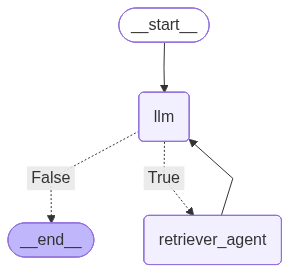

In [14]:
from IPython.display import display, Image
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [29]:
# ==========================================
# CELL 5: QUERY INTERFACE
# ==========================================
def query(patient_id: str, question: str):
    """User-facing interface to interact with the RAG agent."""
    print(f"\n👤 QUESTION: {question} (Patient: {patient_id})")
    
    # Force the LLM to know the current patient context via System Prompt
    sys_prompt = SystemMessage(
        content=f"""AgentState"You are a medical AI assistant. You are currently assisting with patient_id: '{patient_id}'.

You must always follow these rules:

Always use the retrieve_patient_records tool before answering any medical question.
Base your answer only on the retrieved medical records.
Do not guess or invent any medical information.
If the information needed to answer the question is not found in the medical records, you must clearly say:
'No relevant information is available in the medical records for this question: {question}.'
If information exists, summarize it clearly and simply for the user.
Keep answers accurate, short, and medically safe.
"""
    )
    user_msg = HumanMessage(content=question)
    
    inputs = {"messages": [sys_prompt, user_msg]}
    
    # Run the graph and get final output
    final_state = rag_agent.invoke(inputs)
    final_message = final_state["messages"][-1]
    
    print(f"🤖 ANSWER: {final_message.content}")
    print("-" * 50)

In [20]:
# ==========================================
# CELL 6: MOCK DATA GENERATION (WITH PATH)
# ==========================================
import os

def create_mock_pdf(filename, text):
    """Helper to generate local PDFs for testing inside a specific directory."""
    # 1. Définir le dossier de destination
    target_dir = "./fils"
    
    # 2. Créer le dossier s'il n'existe pas encore
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"📁 Dossier créé : {target_dir}")
        
    # 3. Combiner le dossier et le nom du fichier
    full_path = os.path.join(target_dir, filename)
    
    # 4. Générer le PDF
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)
    pdf.multi_cell(0, 10, txt=text)
    
    # 5. Sauvegarder dans le chemin complet
    pdf.output(full_path)



In [ ]:
# create_mock_pdf(
#     "p3_visit1.pdf",
#     """
# Patient ID: PT-015
# Visit Date: 12 April

# Complaint:
# - Persistent cough and mild fever

# Diagnosis:
# - Acute bronchitis (likely viral)

# Treatment:
# - Paracetamol for fever
# - Increased fluid intake
# - Rest

# Follow-up:
# - If symptoms persist more than 7 days
# """
# )

# create_mock_pdf(
#     "p4_visit1.pdf",
#     """
# Patient ID: PT-022
# Visit Date: 03 May

# Complaint:
# - High blood pressure detected during routine check

# Diagnosis:
# - Stage 1 hypertension

# Plan:
# - Lifestyle modification (low salt diet, exercise)
# - Monitor BP weekly

# No medication prescribed yet
# """
# )

# create_mock_pdf(
#     "p5_visit1.pdf",
#     """
# Patient ID: PT-030
# Visit Date: 18 June

# Complaint:
# - Severe headache and nausea

# Assessment:
# - Migraine episode

# Treatment:
# - Pain relief medication (Ibuprofen)
# - Rest in dark room

# Advice:
# - Reduce stress
# - Avoid screen exposure during episodes
# """
# )

# create_mock_pdf(
#     "p1_visit3.pdf",
#     """
# Patient ID: PT-001
# Visit Date: 10 April

# Status:
# - Asthma significantly improved under corticosteroid therapy

# Plan:
# - Continue corticosteroid daily
# - Reduce reliance on rescue inhaler

# Notes:
# - Patient shows good response to treatment
# """
# )

# create_mock_pdf(
#     "p6_visit1.pdf",
#     """
# Patient ID: PT-045
# Visit Date: 22 July

# Complaint:
# - Lower back pain after lifting heavy object

# Diagnosis:
# - Muscle strain

# Treatment:
# - Pain relievers
# - Rest for 5 days
# - Physical therapy recommended if pain persists

# Warning signs:
# - Seek care if numbness occurs
# """
# )

In [ ]:
# phat ='/home/hicham/Desktop/RAG_médical/backend/app/rag/fils'

In [ ]:
# add_file("./fils/p1_visit3.pdf", patient_id="PT-001", file_id="doc-v1")

📄 Added 1 chunks for file_id: 'doc-v1' (patient_id: PT-001)


In [ ]:
# add_file("./fils/p3_visit1.pdf", patient_id="PT-001", file_id="doc-v2")
# add_file("./fils/p4_visit1.pdf", patient_id="PT-001", file_id="doc-v2")
# add_file("./fils/p5_visit1.pdf", patient_id="PT-001", file_id="doc-v2")
# add_file("./fils/p6_visit1.pdf", patient_id="PT-001", file_id="doc-v2")

📄 Added 1 chunks for file_id: 'doc-v2' (patient_id: PT-001)
📄 Added 1 chunks for file_id: 'doc-v2' (patient_id: PT-001)
📄 Added 1 chunks for file_id: 'doc-v2' (patient_id: PT-001)
📄 Added 1 chunks for file_id: 'doc-v2' (patient_id: PT-001)


In [ ]:
# add_file("./fils/p3_visit1.pdf", patient_id="PT-002", file_id="doc-v2")


📄 Added 1 chunks for file_id: 'doc-v2' (patient_id: PT-002)


In [ ]:
# query("PT-002", "What is the patient’s blood type?")


👤 QUESTION: What is the patient’s blood type? (Patient: PT-002)
   [Tool Call] 🔍 Searching records for Patient: PT-002 | Query: blood type
🤖 ANSWER: No relevant information is available in the medical records for this question: What is the patient’s blood type?.
--------------------------------------------------


In [ ]:
# query("PT-001", "What was prescribed to the patient during their visits?")


👤 QUESTION: What was prescribed to the patient during their visits? (Patient: PT-001)
   [Tool Call] 🔍 Searching records for Patient: PT-001 | Query: What was prescribed to the patient during their visits?
🤖 ANSWER: **Prescribed treatments from the medical records for PT-001:**

- **Visit on 10 April**: Continue corticosteroid daily; reduce reliance on rescue inhaler.

No other visits or prescriptions are documented for this patient.
--------------------------------------------------


In [ ]:
# # ==========================================
# # CELL 7: TEST EXAMPLES
# # ==========================================


# query("PT-001", "What was prescribed to the patient during their visits?")

# print("\n=== 🧪 TEST 2: QUERY WITH PATIENT FILTER ===")
# # Even though we ask about ankle, it should filter by PT-001 and not find PT-009's data
# query("PT-001", "Does the patient have a sprained ankle?") 

# print("\n=== 🧪 TEST 3: UPDATE RULE ===")
# # Update doc-v1 for PT-001 (Delete old chunks, insert updated ones)
# update_file("p1_visit1_updated.pdf", patient_id="PT-001", file_id="doc-v1")

# query("PT-001", "What was the exact diagnosis and prescription on the Jan 10 visit?")